## PART 1. Setup — Dependencies & API Clients

In [ ]:
# INSTALL IN ACTIVE NOTEBOOK KERNEL
%pip install python-dotenv google-genai openai anthropic matplotlib pyreadstat

In [1]:
# Core utilities
from dotenv import load_dotenv
import os
import time
import re
import json

# Data + modeling
import pyreadstat
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from scipy.spatial.distance import jensenshannon
from collections import defaultdict
import matplotlib.pyplot as plt

# Gemini API SDK
import google.genai as genai
from google.genai import types

# ChatGPT API SDK
from openai import OpenAI

# Claude API SDK
from anthropic import Anthropic

print("Imports ready:", pd.__version__)

Imports ready: 3.0.2


In [2]:
# Load environment variables once.
load_dotenv()

# API keys and local endpoint config (kept in one place for easier debugging)
GEMINI_API_KEY = os.environ.get('GEMINI_API_KEY')
OPENAI_API_KEY = os.environ.get('OPENAI_API_KEY')
ANTHROPIC_API_KEY = os.environ.get('ANTHROPIC_API_KEY')

# Llama local API config: these can be set in the .env file or default to these values for easy local testing.
LLAMA_BASE_URL = os.environ.get('LLAMA_BASE_URL', 'http://localhost:1234/v1')
LLAMA_API_KEY = os.environ.get('LLAMA_API_KEY')
LLAMA_MODEL_ID = os.environ.get('LLAMA_MODEL_ID', 'llama-3.1-swallow-8b-instruct-v0.2-i1')

# Client registry: initialize available clients and keep missing ones as None.
clients = {
    'gemini': genai.Client(api_key=GEMINI_API_KEY) if GEMINI_API_KEY else None,
    'chatgpt': OpenAI(api_key=OPENAI_API_KEY) if OPENAI_API_KEY else None,
    'claude': Anthropic(api_key=ANTHROPIC_API_KEY) if ANTHROPIC_API_KEY else None,
    'llama': OpenAI(base_url=LLAMA_BASE_URL, api_key=LLAMA_API_KEY),
}

print("Client status:")
for name, c in clients.items():
    print(f"- {name}: {'ready' if c is not None else 'missing API key'}")

print(f"Llama local endpoint: {LLAMA_BASE_URL}")
print(f"Llama model id: {LLAMA_MODEL_ID}")

Client status:
- gemini: ready
- chatgpt: ready
- claude: ready
- llama: ready
Llama local endpoint: http://localhost:1234/v1
Llama model id: llama-3.1-swallow-8b-instruct-v0.2-i1


## PART 2. Configuration
All tunable parameters live here. Re-run this cell whenever you change a setting — no kernel restart needed.

In [24]:
# ---------------------------------------------------------------------------
# RF feature selection
# ---------------------------------------------------------------------------
K_ACCUM          = 10     # top features accumulated per RF model (fixed, per German paper)
MIN_VALID_RATE   = 0.75   # drop RF pool vars with fewer valid responses than this
TOP_K_VALUES     = [2, 4, 8, 16, 32, 64, 128]  # persona sizes to build and compare

# Variables that measure the same concept — any slice containing more than one triggers a warning
COLLINEARITY_GROUPS = {
    "Father's occupation": ["ppjxxe08", "ppjbxx15"],
    "Income (respondent)": ["szincoma", "szincomx"],
    "Income (spouse)":     ["ssszinca", "ssszincm"],
}

# ---------------------------------------------------------------------------
# Persona & simulation
# ---------------------------------------------------------------------------
ACTIVE_PERSONA_K     = 8      # which top-k slice feeds the simulation (must be in TOP_K_VALUES)
MAX_PERSONAS         = 50     # safety cap on API calls — set to None for a full run (2,660)

# ACTIVE_QUESTION_KEYS = ['op4trust', 'stalllf', 'q5gveqaa']  # subset of ALL_QUESTIONS to run

ACTIVE_QUESTION_KEYS = [
    'op4trust', 'tr3cgmnz', 'tr3bcraz',        # Trust
    'qfnrincr', 'q4samesm', 'op7gdevo',        # Ethnocentrism
    'q7wwhhx',  'q7jbmmcc', 'q7mgcc',          # Gender & family norms
    'q5gveqaa', 'opincdif', 'opnucpol',        # Social inequality
    'stalllf',  'nofutr',   'sfmhdprs', 'op5happz',  # Wellbeing
    'opnbmtcn', 'wllive',   'mempltgp',        # Community & civic
]


# ---------------------------------------------------------------------------
# LLM models
# ---------------------------------------------------------------------------
MODEL_CONFIG = {
    'gemini':  {'model_id': 'gemini-2.5-flash', 'sleep_seconds': 1.0},
    'chatgpt': {'model_id': 'gpt-4o-mini',      'sleep_seconds': 1.0},
    'claude':  {'model_id': 'claude-haiku-4-5', 'sleep_seconds': 1.0},
    'llama':   {'model_id': LLAMA_MODEL_ID,     'sleep_seconds': 0.0},
}

# Approximate USD cost per 1M tokens — update if provider pricing changes
COST_PER_1M = {
    'gemini':  {'input': 0.075, 'output': 0.30},
    'chatgpt': {'input': 0.150, 'output': 0.60},
    'claude':  {'input': 0.800, 'output': 4.00},
    'llama':   {'input': 0.000, 'output': 0.00},
}

# ---------------------------------------------------------------------------
# System prompt
# ---------------------------------------------------------------------------
# Minimal role-setter. The actual task framing (perspective-taking, question,
# answer options, completion cue) is built into the user prompt — see Part 8.
sys_instruct = (
    "あなたは日本の社会調査（JGSS）の回答者です。"
    "以下のペルソナの視点に立って、質問に対する回答を選択肢から選んでください。"
)

print("Configuration loaded.")
print(f"  Active persona: TOP-{ACTIVE_PERSONA_K}  |  cap: {MAX_PERSONAS or 'none (full run)'}  |  questions: {ACTIVE_QUESTION_KEYS}")
print(f"  Models: {list(MODEL_CONFIG.keys())}")

Configuration loaded.
  Active persona: TOP-8  |  cap: 50  |  questions: ['op4trust', 'tr3cgmnz', 'tr3bcraz', 'qfnrincr', 'q4samesm', 'op7gdevo', 'q7wwhhx', 'q7jbmmcc', 'q7mgcc', 'q5gveqaa', 'opincdif', 'opnucpol', 'stalllf', 'nofutr', 'sfmhdprs', 'op5happz', 'opnbmtcn', 'wllive', 'mempltgp']
  Models: ['gemini', 'chatgpt', 'claude', 'llama']


## PART 3. Connectivity Check

In [6]:
# Smoke test — one small prompt per client to verify connectivity.
def smoke_test_client(name, client):
    if client is None:
        return False, 'missing API key'
    try:
        if name == 'gemini':
            resp = client.models.generate_content(
                model='gemini-2.5-flash',
                contents='Reply with exactly: pong',
            )
            text = resp.text or ""
        elif name == 'chatgpt':
            resp = client.chat.completions.create(
                model='gpt-4o-mini',
                messages=[{'role': 'user', 'content': 'Reply with exactly: pong'}],
                max_tokens=10,
            )
            text = resp.choices[0].message.content or ""
        elif name == 'claude':
            resp = client.messages.create(
                model='claude-haiku-4-5',
                max_tokens=16,
                messages=[{'role': 'user', 'content': 'Reply with exactly: pong'}],
            )
            text = "".join(b.text for b in resp.content if hasattr(b, "text"))
        elif name == 'llama':
            resp = client.chat.completions.create(
                model=LLAMA_MODEL_ID,
                messages=[{'role': 'user', 'content': 'Reply with exactly: pong'}],
                max_tokens=10,
            )
            text = resp.choices[0].message.content or ""
        else:
            return False, f'no smoke test configured for {name}'
        return True, text.strip()
    except Exception as e:
        return False, f'{type(e).__name__}: {e}'


print('Client smoke test:')
for name, client in clients.items():
    ok, detail = smoke_test_client(name, client)
    print(f'  {name}: {"OK" if ok else "FAIL"} | {detail}')

Client smoke test:
  gemini: OK | pong
  chatgpt: OK | pong
  claude: FAIL | BadRequestError: Error code: 400 - {'type': 'error', 'error': {'type': 'invalid_request_error', 'message': 'Your credit balance is too low to access the Anthropic API. Please go to Plans & Billing to upgrade or purchase credits.'}, 'request_id': 'req_011CbDomNLWV7JWPtjXmjuJ5'}
  llama: OK | Pong


## PART 4. Data

In [7]:
import importlib
import pyreadstat
import config
importlib.reload(config)

DATA_PATH = 'data/20172018_data.sav'

df, meta = pyreadstat.read_sav(DATA_PATH)
df.columns = [c.strip() for c in df.columns]

# Replace JGSS soft missing codes with NaN (9, 99, 999 are "no answer" conventions)
for code in config.MISSING_CODES:
    df.replace(code, np.nan, inplace=True)

# Variable + value label lookups — used by Part 6 to build human-readable personas
# instead of raw numeric codes. Aligns with German paper Appendix B.1 format.
var_labels   = dict(zip(meta.column_names, meta.column_labels))   # var code → description
value_labels = meta.variable_value_labels                          # var code → {numeric value → text}

config.sanity_check(df.columns)
print(f"\nLoaded: {len(df)} respondents × {len(df.columns)} variables")
print(f"Label coverage: {sum(1 for v in var_labels.values() if v)} column labels, "
      f"{len(value_labels)} variables with value labels")

Variable classification check passed:
  Total in dataset:    558
  Excluded:            30
  Core demographics:   10
  Outcomes:            19 across 6 categories
  RF pool (the rest):  499

Loaded: 2660 respondents × 558 variables
Label coverage: 558 column labels, 552 variables with value labels


In [8]:
# RF pool: all variables except EXCLUDES, CORE_DEMOGRAPHICS, and OUTCOMES (never seen by RF)
rf_pool = config.get_rf_pool(df.columns)
n = len(df)
print(f"RF pool: {len(rf_pool)} variables")

# Flag pool variables below the valid-rate threshold
red_flag = {
    var: df[var].notna().sum() / n
    for var in rf_pool
    if df[var].notna().sum() / n < MIN_VALID_RATE
}
print(f"Red-flagged (<{MIN_VALID_RATE:.0%} valid): {len(red_flag)} variables")

RF pool: 499 variables
Red-flagged (<75% valid): 318 variables


## PART 5. RF Feature Selection

In [9]:
# Filtered RF ranking — source of all persona variable slices.
# Only variables with valid rate >= MIN_VALID_RATE enter the pool.
rf_pool_filtered = [v for v in rf_pool if df[v].notna().sum() / n >= MIN_VALID_RATE]
print(f"Filtered RF pool: {len(rf_pool_filtered)} variables  ({len(rf_pool) - len(rf_pool_filtered)} dropped below {MIN_VALID_RATE:.0%})")

imputer_f = SimpleImputer(strategy='most_frequent')
df_rf_filtered = pd.DataFrame(
    imputer_f.fit_transform(df[rf_pool_filtered]),
    columns=rf_pool_filtered,
    index=df.index,
)

master_scores_filtered = defaultdict(float)
for i, target_var in enumerate(rf_pool_filtered):
    X = df_rf_filtered.drop(columns=[target_var])
    y = df_rf_filtered[target_var].astype(str)
    rf = RandomForestClassifier(n_estimators=50, max_features='sqrt', random_state=42, n_jobs=-1)
    rf.fit(X, y)
    importances = pd.Series(rf.feature_importances_, index=X.columns)
    for feat, score in importances.nlargest(K_ACCUM).items():
        master_scores_filtered[feat] += score
    if (i + 1) % 50 == 0:
        print(f"  {i + 1}/{len(rf_pool_filtered)} done")

sorted_ranking_filtered = sorted(master_scores_filtered.items(), key=lambda x: x[1], reverse=True)

# One ranking, sliced at each top-k cutpoint
persona_slices = {
    k: [var for var, _ in sorted_ranking_filtered[:k]]
    for k in TOP_K_VALUES
}

# Display ranked list up to the largest k, with cutpoint markers
cutpoints = set(TOP_K_VALUES)
print(f"\n--- FILTERED RF RANKING (≥{MIN_VALID_RATE:.0%} valid, K_ACCUM={K_ACCUM}) ---")
for i, (var, score) in enumerate(sorted_ranking_filtered[:max(TOP_K_VALUES)]):
    rank = i + 1
    label = var_labels.get(var, "")
    rate = df[var].notna().sum() / n
    marker = f"  ◄ TOP-{rank}" if rank in cutpoints else ""
    print(f"  {rank:3d}. {var} — {label}  ({rate:.1%}){marker}")

# Collinearity check at each slice
print()
warned = False
for k in TOP_K_VALUES:
    for group_name, group_vars in COLLINEARITY_GROUPS.items():
        hits = [v for v in group_vars if v in persona_slices[k]]
        if len(hits) > 1:
            print(f"  ⚠ TOP-{k} collinearity — '{group_name}': {hits}")
            warned = True
if not warned:
    print("No collinearity conflicts across any slice.")

Filtered RF pool: 181 variables  (318 dropped below 75%)
  50/181 done
  100/181 done
  150/181 done

--- FILTERED RF RANKING (≥75% valid, K_ACCUM=10) ---
    1. xxfstjb — Occupation of the First Job  (97.2%)
    2. ppjxxe08 — Occupation of Father at Age 15 (ISCO08)  (91.6%)  ◄ TOP-2
    3. age1mg — Age at First Marriage  (82.4%)
    4. incmain — Main Income Source  (99.7%)  ◄ TOP-4
    5. szstffst — Corporation Size of the First Job  (90.8%)
    6. szhsincm — Household Annual Income  (91.2%)
    7. ssszinca — Spouse Annual Income: Overall  (94.7%)
    8. domarry — Marital Status  (100.0%)  ◄ TOP-8
    9. szexed — Educational Costs in Household Expenses  (94.5%)
   10. st5ssrel — Satisfaction with Relationship with Spouse  (99.5%)
   11. hrtv — Hours of Watching TV  (98.9%)
   12. szffonly — Number of Family Members Except Respondent  (99.9%)
   13. szincomx — Respondent Annual Income: Main Job  (94.5%)
   14. szffttl — Number of Family Members Including Respondent  (99.7%)
   15. sssz

## PART 6. Persona Creation

In [25]:
# Build persona profiles for every top-k slice.
# Personas use human-readable labels (variable descriptions as keys,
# "(code) label" strings as values) so the LLM can actually interpret them.
# Mirrors the German paper's Appendix B.1 format: '(3) Mittlere Reife'.
# ACTIVE_PERSONA_K (set in Configuration) selects which set feeds the simulation cells.

def encode_value(var, val, value_labels):
    """Convert a raw JGSS code to '(N) Label' if a value label exists,
    otherwise return the raw number. Continuous variables (age, counts)
    have no value labels and pass through as plain numbers."""
    label = value_labels.get(var, {}).get(float(val))
    val_clean = int(val) if val == int(val) else val
    if label is not None:
        return f"({val_clean}) {label}"
    return val_clean


personas_by_k = {}
for k in TOP_K_VALUES:
    persona_vars = config.CORE_DEMOGRAPHICS + persona_slices[k]
    persona_list = []
    for _, row in df.iterrows():
        persona_dict = {}
        for var in persona_vars:
            val = row.get(var)
            if pd.notna(val):
                key = var_labels.get(var) or var
                persona_dict[key] = encode_value(var, val, value_labels)
        persona_list.append(json.dumps(persona_dict, ensure_ascii=False))
    personas_by_k[k] = persona_list

personas = personas_by_k[ACTIVE_PERSONA_K]

print(f"Built persona sets for top-k: {TOP_K_VALUES}")
print(f"Active: TOP-{ACTIVE_PERSONA_K}  ({len(config.CORE_DEMOGRAPHICS)} core + {ACTIVE_PERSONA_K} RF vars per persona)")
print(f"\nExample persona (TOP-{ACTIVE_PERSONA_K}):")
print(personas[0])

Built persona sets for top-k: [2, 4, 8, 16, 32, 64, 128]
Active: TOP-8  (10 core + 8 RF vars per persona)

Example persona (TOP-8):
{"Sex": "(2) Female", "Age": 76, "Size of Municipality": "(3) Cities with population of less than 200000", "Respondent Annual Income: Overall": "(2) Less than 700,000 yen", "Total Number of Children": 3, "Work Status": "(3) I did not work", "Occupation of the First Job": "(645) Miso/soy sauce/canned food/dairy product makers, food makers", "Occupation of Father at Age 15 (ISCO08)": "(3123) Construction supervisors", "Age at First Marriage": 20, "Main Income Source": "(5) Pension", "Corporation Size of the First Job": "(8) 500-999", "Household Annual Income": "(7) 2.5 million yen - 3.5 million yen", "Spouse Annual Income: Overall": "(6) 1.5 million yen - 2.5 million yen", "Marital Status": "(1) Currently married"}


## PART 7. Checkpoint — Save / Load
### Optional
- Run **Save** after any model completes to protect API results. 
- Run **Load** at the start of a new session to restore without re-running models.

In [27]:
# ---------------------------------------------------------------------------
# SAVE — run after any model cell completes to protect your work.
# Results are keyed by (model, k) so batches never overwrite each other.
# metrics_all.csv accumulates across all runs — never overwritten.
# ---------------------------------------------------------------------------
import datetime
CKPT_DIR = 'data'

# 1. RF importance ranking — computed once, safe to overwrite
rf_ranking_df = pd.DataFrame(sorted_ranking_filtered, columns=['variable', 'importance_score'])
rf_ranking_df['label']      = rf_ranking_df['variable'].map(var_labels)
rf_ranking_df['valid_rate'] = rf_ranking_df['variable'].map(lambda v: df[v].notna().sum() / len(df))
rf_ranking_df.to_csv(f'{CKPT_DIR}/rf_ranking_filtered.csv', index=False)
print(f"Saved RF ranking:    {CKPT_DIR}/rf_ranking_filtered.csv  ({len(rf_ranking_df)} variables)")

# 2. Personas by k — computed once, safe to overwrite
with open(f'{CKPT_DIR}/personas_by_k.json', 'w', encoding='utf-8') as f:
    json.dump({str(k): v for k, v in personas_by_k.items()}, f, ensure_ascii=False, indent=2)
print(f"Saved personas:      {CKPT_DIR}/personas_by_k.json  (k={list(personas_by_k.keys())})")

# 3. Per-model results — filename encodes model AND k, so no batch ever overwrites another
if not results_by_model:
    print("Skipped results:     no model has run yet")
else:
    for model_label, rdf in results_by_model.items():
        path = f'{CKPT_DIR}/results_{model_label}_k{ACTIVE_PERSONA_K}.csv'
        rdf.to_csv(path)
        print(f"Saved results:       {path}  {rdf.shape}")

# 4. Metrics — append new rows to metrics_all.csv; never overwrite historical runs
if metrics_df.empty:
    print("Skipped metrics:     empty (no model has run yet)")
else:
    metrics_path = f'{CKPT_DIR}/metrics_all.csv'
    if os.path.exists(metrics_path):
        existing = pd.read_csv(metrics_path)
        # Remove any rows from this exact (model, persona_k) combo before appending
        # so re-saving after a re-run doesn't create duplicates
        mask = ~(
            existing['model'].isin(metrics_df['model'].unique()) &
            (existing['persona_k'] == ACTIVE_PERSONA_K)
        )
        combined = pd.concat([existing[mask], metrics_df], ignore_index=True)
    else:
        combined = metrics_df.copy()
    combined.to_csv(metrics_path, index=False)
    print(f"Saved metrics:       {metrics_path}  ({len(combined)} total rows, {len(metrics_df)} new)")

# 5. Run log — one row per completed (model, k) batch for progress tracking
if results_by_model and not metrics_df.empty:
    log_path = f'{CKPT_DIR}/run_log.csv'
    log_rows = []
    for model_label in results_by_model:
        m_rows = metrics_df[metrics_df['model'] == model_label]
        log_rows.append({
            'timestamp':  datetime.datetime.now().strftime('%Y-%m-%d %H:%M'),
            'model':      model_label,
            'persona_k':  ACTIVE_PERSONA_K,
            'questions':  ','.join(ACTIVE_QUESTION_KEYS),
            'n_personas': MAX_PERSONAS or len(personas),
            'mean_jsd':   round(m_rows['jsd'].mean(), 4),
            'valid_rate': round((m_rows['valid_answers'] / m_rows['total_personas']).mean(), 3),
        })
    new_log = pd.DataFrame(log_rows)
    if os.path.exists(log_path):
        pd.concat([pd.read_csv(log_path), new_log], ignore_index=True).to_csv(log_path, index=False)
    else:
        new_log.to_csv(log_path, index=False)
    print(f"\nRun log updated:     {log_path}")
    print(new_log.to_string(index=False))

Saved RF ranking:    data/rf_ranking_filtered.csv  (162 variables)
Saved personas:      data/personas_by_k.json  (k=[2, 4, 8, 16, 32, 64, 128])
Saved results:       data/results_llama_k8.csv  (50, 19)
Saved metrics:       data/metrics_all.csv  (57 total rows, 19 new)

Run log updated:     data/run_log.csv
       timestamp model  persona_k                                                                                                                                                          questions  n_personas  mean_jsd  valid_rate
2026-05-20 21:51 llama          8 op4trust,tr3cgmnz,tr3bcraz,qfnrincr,q4samesm,op7gdevo,q7wwhhx,q7jbmmcc,q7mgcc,q5gveqaa,opincdif,opnucpol,stalllf,nofutr,sfmhdprs,op5happz,opnbmtcn,wllive,mempltgp          50     0.314       0.919


In [ ]:
# ---------------------------------------------------------------------------
# LOAD — restore outputs from a previous session without re-running models.
# Loads results for ACTIVE_PERSONA_K specifically; metrics_all.csv loads
# the full history across all k-values (useful for cross-k visualization).
# ---------------------------------------------------------------------------
CKPT_DIR = 'data'

# 1. RF ranking
_path = f'{CKPT_DIR}/rf_ranking_filtered.csv'
if os.path.exists(_path):
    rf_ranking_df = pd.read_csv(_path)
    sorted_ranking_filtered = list(zip(rf_ranking_df['variable'], rf_ranking_df['importance_score']))
    print(f"Loaded RF ranking:   {_path}  ({len(sorted_ranking_filtered)} variables)")
else:
    print(f"Not found (skipped): {_path}")

# 2. Personas by k
_path = f'{CKPT_DIR}/personas_by_k.json'
if os.path.exists(_path):
    with open(_path, encoding='utf-8') as f:
        _raw = json.load(f)
    personas_by_k = {int(k): v for k, v in _raw.items()}
    personas = personas_by_k[ACTIVE_PERSONA_K]
    print(f"Loaded personas:     {_path}  (k={list(personas_by_k.keys())}, active=TOP-{ACTIVE_PERSONA_K})")
else:
    print(f"Not found (skipped): {_path}")

# 3. Per-model results for the active k — results_{model}_k{k}.csv
results_by_model = {}
for model_label in MODEL_CONFIG:
    _path = f'{CKPT_DIR}/results_{model_label}_k{ACTIVE_PERSONA_K}.csv'
    if os.path.exists(_path):
        results_by_model[model_label] = pd.read_csv(_path, index_col=0)
        print(f"Loaded results:      {_path}  {results_by_model[model_label].shape}")
    else:
        print(f"Not found (skipped): {_path}")

# 4. Full metrics history across all batches
_path = f'{CKPT_DIR}/metrics_all.csv'
if os.path.exists(_path):
    metrics_df = pd.read_csv(_path)
    metrics_rows = metrics_df.to_dict('records')
    runs = metrics_df.groupby(['model', 'persona_k']).size().reset_index(name='questions')
    print(f"Loaded metrics:      {_path}  ({len(metrics_df)} rows across {len(runs)} completed runs)")
    print(runs.to_string(index=False))
else:
    metrics_df = pd.DataFrame()
    metrics_rows = []
    print(f"Not found (skipped): {_path}  — metrics_df is empty")

# 5. Show run log if available
_path = f'{CKPT_DIR}/run_log.csv'
if os.path.exists(_path):
    print(f"\nRun log ({_path}):")
    print(pd.read_csv(_path).to_string(index=False))
else:
    print(f"\nNo run log yet.")

## PART 8. Simulation Build and Parameters

In [20]:
# ---------------------------------------------------------------------------
# Full JGSS-2017/2018 question bank (all 19 outcome variables).
# Completion-style layout: question text and answer options are kept SEPARATE,
# mirroring the German paper's Appendix B.1 prompt structure.
# ACTIVE_QUESTION_KEYS (set in Configuration) selects which questions actually run.
# ---------------------------------------------------------------------------
ALL_QUESTIONS = {
    # --- Trust ---
    'op4trust': {
        'question': "一般的に言って、人は信頼できると思いますか？",
        'options':  ["1: 信頼できる", "2: ほぼ信頼できる", "3: あまり信頼できない", "4: 信頼できない"],
        'scale_min': 1, 'scale_max': 4,
    },
    'tr3cgmnz': {
        'question': "国会議員をどの程度信頼していますか？",
        'options':  ["1: 非常に信頼", "2: やや信頼", "3: あまり信頼しない", "4: 全く信頼しない"],
        'scale_min': 1, 'scale_max': 4,
    },
    'tr3bcraz': {
        'question': "省庁・政府機関をどの程度信頼していますか？",
        'options':  ["1: 非常に信頼", "2: やや信頼", "3: あまり信頼しない", "4: 全く信頼しない"],
        'scale_min': 1, 'scale_max': 4,
    },
    # --- Ethnocentrism ---
    'qfnrincr': {
        'question': "日本の外国人を増やすべきだと思いますか？",
        'options':  ["1: 増やすべき", "2: 増やすべきでない"],
        'scale_min': 1, 'scale_max': 2,
    },
    'q4samesm': {
        'question': "同性婚についてどうお考えですか？",
        'options':  ["1: 強く賛成", "2: 賛成", "3: 反対", "4: 強く反対"],
        'scale_min': 1, 'scale_max': 4,
    },
    'op7gdevo': {
        'question': "人間の本質について、1（非常に自己中心的）から7（非常に善良）のどこに当てはまりますか？",
        'options':  ["1: 非常に自己中心的", "2", "3", "4", "5", "6", "7: 非常に善良"],
        'scale_min': 1, 'scale_max': 7,
    },
    # --- Gender & family norms ---
    'q7wwhhx': {
        'question': "「男性は外で働き、女性は家庭を守るべきだ」という考えに同意しますか？",
        'options':  ["1: 強く同意", "2", "3", "4", "5", "6", "7: 強く反対"],
        'scale_min': 1, 'scale_max': 7,
    },
    'q7jbmmcc': {
        'question': "「母親が働くと子どもに悪影響がある」という考えに同意しますか？",
        'options':  ["1: 強く同意", "2", "3", "4", "5", "6", "7: 強く反対"],
        'scale_min': 1, 'scale_max': 7,
    },
    'q7mgcc': {
        'question': "「結婚したカップルは子どもを持つべきだ」という考えに同意しますか？",
        'options':  ["1: 強く同意", "2", "3", "4", "5", "6", "7: 強く反対"],
        'scale_min': 1, 'scale_max': 7,
    },
    # --- Social inequality ---
    'q5gveqaa': {
        'question': "政府は所得格差を縮小する責任があると思いますか？",
        'options':  ["1: 強く同意", "2: 同意", "3: どちらでもない", "4: 反対", "5: 強く反対"],
        'scale_min': 1, 'scale_max': 5,
    },
    'opincdif': {
        'question': "所得格差は大きくなりすぎていると思いますか？",
        'options':  ["1: 強くそう思う", "2: そう思う", "3: ややそう思う", "4: どちらでもない",
                     "5: あまりそう思わない", "6: そう思わない", "7: 全くそう思わない"],
        'scale_min': 1, 'scale_max': 7,
    },
    'opnucpol': {
        'question': "原子力政策についてどうお考えですか？",
        'options':  ["1: 積極的に推進", "2: 推進", "3: 現状維持", "4: 削減", "5: 即時廃止"],
        'scale_min': 1, 'scale_max': 5,
    },
    # --- Wellbeing ---
    'stalllf': {
        'question': "現在の生活全体にどの程度満足していますか？",
        'options':  ["1: 非常に満足", "2: 満足", "3: どちらでもない", "4: 不満", "5: 非常に不満"],
        'scale_min': 1, 'scale_max': 5,
    },
    'nofutr': {
        'question': "将来に希望が持てないと感じますか？",
        'options':  ["1: 強くそう思う", "2: そう思う", "3: どちらでもない", "4: そう思わない", "5: 全くそう思わない"],
        'scale_min': 1, 'scale_max': 5,
    },
    'sfmhdprs': {
        'question': "過去4週間で、気分が落ち込んだり憂うつになったりすることがありましたか？",
        'options':  ["1: いつもあった", "2: たびたびあった", "3: ときどきあった", "4: まれにあった", "5: 全くなかった"],
        'scale_min': 1, 'scale_max': 5,
    },
    'op5happz': {
        'question': "あなたは幸福だと思いますか？",
        'options':  ["1: 非常に幸福", "2: 幸福", "3: どちらでもない", "4: 不幸", "5: 非常に不幸"],
        'scale_min': 1, 'scale_max': 5,
    },
    # --- Community & civic ---
    'opnbmtcn': {
        'question': "近所の人々は互いに気にかけ合っていると思いますか？",
        'options':  ["1: 非常にそう思う", "2: そう思う", "3: どちらでもない", "4: そう思わない", "5: 全くそう思わない"],
        'scale_min': 1, 'scale_max': 5,
    },
    'wllive': {
        'question': "現在住んでいる地域に住み続けたいと思いますか？",
        'options':  ["1: 強くそう思う", "2: そう思う", "3: そう思わない", "4: 全くそう思わない"],
        'scale_min': 1, 'scale_max': 4,
    },
    'mempltgp': {
        'question': "政治団体や市民運動に参加していますか？",
        'options':  ["1: 参加している", "2: 参加していない"],
        'scale_min': 1, 'scale_max': 2,
    },
}

question_bank = {key: ALL_QUESTIONS[key] for key in ACTIVE_QUESTION_KEYS}

# Precompute real distributions once and reuse across models
real_distributions = {
    var_name: df[var_name]
        .dropna()
        .astype(int)
        .value_counts(normalize=True)
        .sort_index()
        .reindex(range(spec['scale_min'], spec['scale_max'] + 1), fill_value=0)
    for var_name, spec in question_bank.items()
}

# One DataFrame per model: results_by_model['gemini'] has columns = active question vars
results_by_model = {}
metrics_rows = []
metrics_df = pd.DataFrame()

# Token usage accumulator — reset per model run, updated by each generate function
token_usage = {m: {'input': 0, 'output': 0, 'calls': 0} for m in MODEL_CONFIG}


def build_user_prompt(persona_json, spec):
    """Completion-style prompt — mirrors German paper Appendix B.1.
    Persona attributes, then question + answer options listed separately,
    ending with '回答：(' so the model completes with the chosen digit."""
    options_str = str(spec['options'])  # e.g., "['1: 信頼できる', '2: ...']"
    return (
        f"以下の特徴を持つ人物の視点に立ってください：{persona_json}\n\n"
        f"次の質問に対するこの人物の回答はどの選択肢ですか：{spec['question']}\n"
        f"回答選択肢：{options_str}\n"
        f"回答：("
    )


def extract_first_int(raw_text, scale_min, scale_max):
    """Extract the first integer from raw_text; return None if missing or out of range."""
    m = re.search(r"\d+", raw_text or "")
    if not m:
        return None
    val = int(m.group())
    return val if scale_min <= val <= scale_max else None


def reset_model_outputs(model_label):
    """Clear stored results, metrics, and token counts for this model."""
    global metrics_rows
    results_by_model.pop(model_label, None)
    metrics_rows = [r for r in metrics_rows if r.get('model') != model_label]
    token_usage[model_label] = {'input': 0, 'output': 0, 'calls': 0}


def record_metrics(model_label, var_name, simulated_answers, all_values, persona_k):
    real_dist = real_distributions[var_name]
    sim_series = pd.Series(simulated_answers).dropna().astype(int)
    sim_dist = sim_series.value_counts(normalize=True).reindex(all_values, fill_value=0)
    valid_n = int(sim_series.notna().sum())

    if sim_dist.sum() == 0:
        jsd_score = None
        print(f"  {var_name}: no valid responses — JSD skipped")
    else:
        jsd_score = float(jensenshannon(real_dist, sim_dist))
        print(f"  {var_name}: JSD={jsd_score:.4f}  valid={valid_n}/{len(simulated_answers)}")

    return {
        'model': model_label,
        'question_var': var_name,
        'persona_k': persona_k,
        'valid_answers': valid_n,
        'total_personas': len(simulated_answers),
        'jsd': jsd_score,
    }


def print_token_summary(model_label):
    u = token_usage[model_label]
    if u['calls'] == 0:
        return
    rates = COST_PER_1M.get(model_label, {'input': 0, 'output': 0})
    cost = u['input'] / 1e6 * rates['input'] + u['output'] / 1e6 * rates['output']
    avg_in = u['input'] / u['calls']
    print(f"\nToken usage — {model_label}:")
    print(f"  Calls:      {u['calls']:,}")
    print(f"  Input:      {u['input']:,} tokens  (avg {avg_in:.0f} / call)")
    print(f"  Output:     {u['output']:,} tokens")
    print(f"  Est. cost:  ${cost:.4f}  "
          f"(@ ${rates['input']}/1M in, ${rates['output']}/1M out)")


def run_model_simulation(model_label, generate_fn):
    global metrics_rows, metrics_df
    reset_model_outputs(model_label)

    active_personas = personas[:MAX_PERSONAS] if MAX_PERSONAS is not None else personas
    model_results = pd.DataFrame(index=df.index[:len(active_personas)])

    for var_name, spec in question_bank.items():
        all_values = range(spec['scale_min'], spec['scale_max'] + 1)
        simulated_answers = []
        print(f"\n[{model_label}] {var_name} (scale {spec['scale_min']}–{spec['scale_max']})")

        for i, persona_json in enumerate(active_personas):
            try:
                raw = generate_fn(build_user_prompt(persona_json, spec))
                answer = extract_first_int(raw, spec['scale_min'], spec['scale_max'])
                simulated_answers.append(answer)
            except Exception as e:
                print(f"  respondent {i+1} error: {e}")
                simulated_answers.append(None)
            time.sleep(MODEL_CONFIG[model_label]['sleep_seconds'])

            if (i + 1) % 500 == 0 or (i + 1) == len(active_personas):
                done = sum(1 for a in simulated_answers if a is not None)
                print(f"  {i+1}/{len(active_personas)} personas  ({done} valid so far)")

        model_results[var_name] = simulated_answers
        metrics_rows.append(
            record_metrics(model_label, var_name, simulated_answers, all_values, ACTIVE_PERSONA_K)
        )

    results_by_model[model_label] = model_results
    metrics_df = pd.DataFrame(metrics_rows)
    print(f"\n{model_label} done.")
    print_token_summary(model_label)


_cap = f"capped at {MAX_PERSONAS}" if MAX_PERSONAS is not None else "full run"
print(f"Active questions: {list(question_bank.keys())}")
print(f"Personas to simulate: {len(personas)}  (TOP-{ACTIVE_PERSONA_K}, {_cap})")
print(f"API calls per model:  {(MAX_PERSONAS or len(personas)) * len(question_bank)}")
print("Helpers ready.")

Active questions: ['op4trust', 'tr3cgmnz', 'tr3bcraz', 'qfnrincr', 'q4samesm', 'op7gdevo', 'q7wwhhx', 'q7jbmmcc', 'q7mgcc', 'q5gveqaa', 'opincdif', 'opnucpol', 'stalllf', 'nofutr', 'sfmhdprs', 'op5happz', 'opnbmtcn', 'wllive', 'mempltgp']
Personas to simulate: 2660  (TOP-16, capped at 50)
API calls per model:  950
Helpers ready.


## PART 9. LLMs

## Gemini

In [ ]:
def gemini_generate_raw_text(user_prompt):
    gemini_client = clients['gemini']
    if gemini_client is None:
        raise ValueError("GEMINI_API_KEY is missing")

    response = gemini_client.models.generate_content(
        model=MODEL_CONFIG['gemini']['model_id'],
        contents=user_prompt,
        config=types.GenerateContentConfig(
            system_instruction=sys_instruct,
            temperature=0.7,
        ),
    )
    u = response.usage_metadata
    token_usage['gemini']['input']  += u.prompt_token_count or 0
    token_usage['gemini']['output'] += u.candidates_token_count or 0
    token_usage['gemini']['calls']  += 1
    return response.text or ""


run_model_simulation('gemini', gemini_generate_raw_text)

## ChatGPT

In [ ]:
def chatgpt_generate_raw_text(user_prompt):
    client = clients['chatgpt']
    if client is None:
        raise ValueError("OPENAI_API_KEY is missing")

    resp = client.chat.completions.create(
        model=MODEL_CONFIG['chatgpt']['model_id'],
        messages=[
            {'role': 'system', 'content': sys_instruct},
            {'role': 'user',   'content': user_prompt},
        ],
        temperature=0.7,
        max_tokens=10,
    )
    token_usage['chatgpt']['input']  += resp.usage.prompt_tokens
    token_usage['chatgpt']['output'] += resp.usage.completion_tokens
    token_usage['chatgpt']['calls']  += 1
    return resp.choices[0].message.content or ""


run_model_simulation('chatgpt', chatgpt_generate_raw_text)

## Claude

In [ ]:
def claude_generate_raw_text(user_prompt):
    claude_client = clients['claude']
    if claude_client is None:
        raise ValueError("ANTHROPIC_API_KEY is missing")

    response = claude_client.messages.create(
        model=MODEL_CONFIG['claude']['model_id'],
        system=sys_instruct,
        max_tokens=10,
        temperature=0.7,
        messages=[{"role": "user", "content": user_prompt}],
    )
    token_usage['claude']['input']  += response.usage.input_tokens
    token_usage['claude']['output'] += response.usage.output_tokens
    token_usage['claude']['calls']  += 1
    return "".join(block.text for block in response.content if hasattr(block, "text"))


run_model_simulation('claude', claude_generate_raw_text)

## Llama

In [26]:
def llama_generate_raw_text(user_prompt):
    client = clients['llama']
    if client is None:
        raise ValueError("Llama client is not initialized")

    resp = client.chat.completions.create(
        model=MODEL_CONFIG['llama']['model_id'],
        messages=[
            {'role': 'system', 'content': sys_instruct},
            {'role': 'user',   'content': user_prompt},
        ],
        temperature=0.7,
        max_tokens=10,
    )
    token_usage['llama']['input']  += resp.usage.prompt_tokens
    token_usage['llama']['output'] += resp.usage.completion_tokens
    token_usage['llama']['calls']  += 1
    return resp.choices[0].message.content or ""


run_model_simulation('llama', llama_generate_raw_text)


[llama] op4trust (scale 1–4)
  50/50 personas  (50 valid so far)
  op4trust: JSD=0.5107  valid=50/50

[llama] tr3cgmnz (scale 1–4)
  50/50 personas  (44 valid so far)
  tr3cgmnz: JSD=0.1781  valid=44/50

[llama] tr3bcraz (scale 1–4)
  50/50 personas  (42 valid so far)
  tr3bcraz: JSD=0.3424  valid=42/50

[llama] qfnrincr (scale 1–2)
  50/50 personas  (50 valid so far)
  qfnrincr: JSD=0.0083  valid=50/50

[llama] q4samesm (scale 1–4)
  50/50 personas  (33 valid so far)
  q4samesm: JSD=0.2987  valid=33/50

[llama] op7gdevo (scale 1–7)
  50/50 personas  (42 valid so far)
  op7gdevo: JSD=0.2539  valid=42/50

[llama] q7wwhhx (scale 1–7)
  50/50 personas  (44 valid so far)
  q7wwhhx: JSD=0.3922  valid=44/50

[llama] q7jbmmcc (scale 1–7)
  50/50 personas  (44 valid so far)
  q7jbmmcc: JSD=0.5944  valid=44/50

[llama] q7mgcc (scale 1–7)
  50/50 personas  (48 valid so far)
  q7mgcc: JSD=0.5118  valid=48/50

[llama] q5gveqaa (scale 1–5)
  50/50 personas  (48 valid so far)
  q5gveqaa: JSD=0.3240

## PART 10. Results Visualization
Run after one or more model cells have completed.

JSD (lower = better):
model          llama
question_var        
mempltgp      0.0038
nofutr        0.2536
op4trust      0.5107
op5happz      0.3236
op7gdevo      0.2539
opincdif      0.3443
opnbmtcn      0.3065
opnucpol      0.3993
q4samesm      0.2987
q5gveqaa      0.3240
q7jbmmcc      0.5944
q7mgcc        0.5118
q7wwhhx       0.3922
qfnrincr      0.0083
sfmhdprs      0.2886
stalllf       0.3544
tr3bcraz      0.3424
tr3cgmnz      0.1781
wllive        0.2766


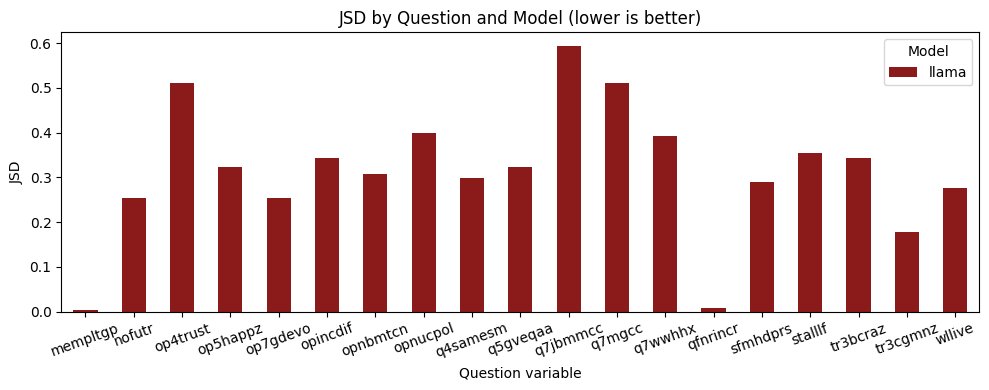


Valid answer rate:
model         llama
question_var       
mempltgp       1.00
nofutr         0.92
op4trust       1.00
op5happz       1.00
op7gdevo       0.84
opincdif       0.92
opnbmtcn       0.98
opnucpol       0.86
q4samesm       0.66
q5gveqaa       0.96
q7jbmmcc       0.88
q7mgcc         0.96
q7wwhhx        0.88
qfnrincr       1.00
sfmhdprs       0.98
stalllf        0.90
tr3bcraz       0.84
tr3cgmnz       0.88
wllive         1.00


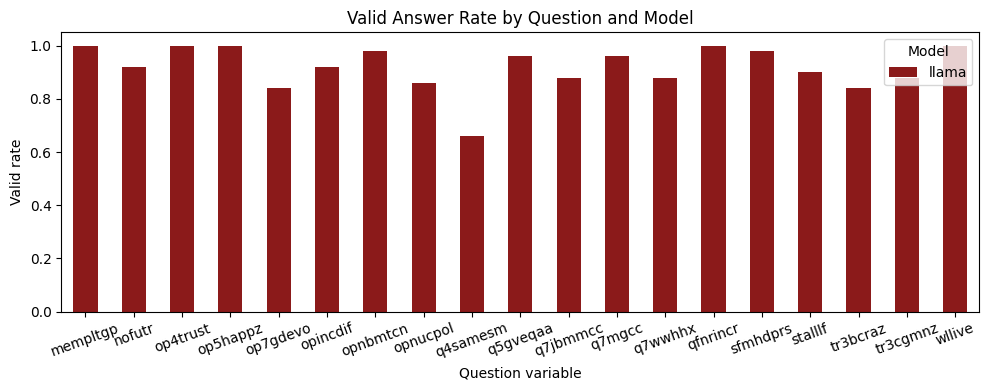


Distribution comparison — op4trust:
    real  llama
1  0.027   0.66
2  0.499   0.18
3  0.412   0.14
4  0.062   0.02


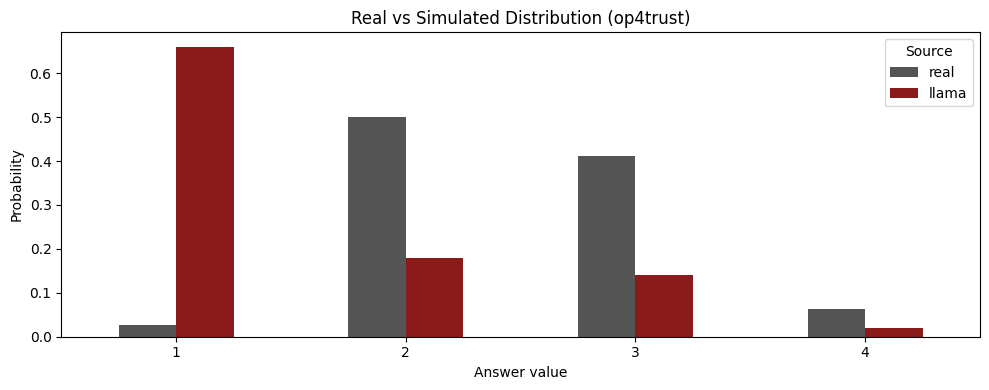

In [28]:
if 'metrics_df' not in globals() or metrics_df.empty:
    raise ValueError("metrics_df is empty — run model cells first.")
if not results_by_model:
    raise ValueError("results_by_model is empty — run model cells first.")

model_order = [m for m in ['gemini', 'chatgpt', 'claude', 'llama'] if m in metrics_df['model'].unique()]
if not model_order:
    raise ValueError("No model results in metrics_df.")

# Consistent color palette across all plots
MODEL_COLORS = {
    'gemini':  '#4A90D9',   # blue
    'chatgpt': '#27AE60',   # green
    'claude':  '#E67E22',   # orange
    'llama':   '#8B1A1A',   # dark red
    'real':    '#555555',   # dark grey
}

plot_df = metrics_df.copy()
plot_df['jsd'] = pd.to_numeric(plot_df['jsd'], errors='coerce')
plot_df['valid_rate'] = plot_df['valid_answers'] / plot_df['total_personas']

# 1) JSD by question and model
jsd_pivot = plot_df.pivot(index='question_var', columns='model', values='jsd').reindex(columns=model_order)
colors = [MODEL_COLORS[m] for m in jsd_pivot.columns]
print("JSD (lower = better):")
print(jsd_pivot.round(4))
ax = jsd_pivot.plot(kind='bar', figsize=(10, 4), rot=20, color=colors)
ax.set_title('JSD by Question and Model (lower is better)')
ax.set_xlabel('Question variable')
ax.set_ylabel('JSD')
ax.legend(title='Model')
plt.tight_layout(); plt.show()

# 2) Valid answer rate
valid_pivot = plot_df.pivot(index='question_var', columns='model', values='valid_rate').reindex(columns=model_order)
colors = [MODEL_COLORS[m] for m in valid_pivot.columns]
print("\nValid answer rate:")
print(valid_pivot.round(3))
ax = valid_pivot.plot(kind='bar', figsize=(10, 4), rot=20, color=colors)
ax.set_title('Valid Answer Rate by Question and Model')
ax.set_xlabel('Question variable')
ax.set_ylabel('Valid rate')
ax.set_ylim(0, 1.05)
ax.legend(title='Model')
plt.tight_layout(); plt.show()

# 3) Distribution comparison for one question
viz_var = list(question_bank.keys())[0]   # change as needed
all_values = list(range(question_bank[viz_var]['scale_min'], question_bank[viz_var]['scale_max'] + 1))
dist_data = {
    'real': df[viz_var].dropna().astype(int)
        .value_counts(normalize=True).sort_index()
        .reindex(all_values, fill_value=0)
}
for m in model_order:
    if m in results_by_model and viz_var in results_by_model[m].columns:
        dist_data[m] = (
            results_by_model[m][viz_var].dropna().astype(int)
            .value_counts(normalize=True).sort_index()
            .reindex(all_values, fill_value=0)
        )

dist_df = pd.DataFrame(dist_data, index=all_values)
colors = [MODEL_COLORS[col] for col in dist_df.columns]
print(f"\nDistribution comparison — {viz_var}:")
print(dist_df.round(3))
ax = dist_df.plot(kind='bar', figsize=(10, 4), rot=0, color=colors)
ax.set_title(f'Real vs Simulated Distribution ({viz_var})')
ax.set_xlabel('Answer value')
ax.set_ylabel('Probability')
ax.legend(title='Source')
plt.tight_layout(); plt.show()

## Archive — Reference Code
Code blocks below are kept for reference only and are **not part of the active pipeline**. They are wrapped in triple-quoted strings so they never execute accidentally.

In [ ]:
""" # Leave-one-out RF ranking over the full RF pool (unfiltered).
# Kept for reference — use the filtered ranking (6b90c8be) for actual persona construction.
# This version ran on the unfiltered pool (includes low-valid-rate variables) and
# produced master_importance_scores / sorted_ranking.
master_importance_scores = defaultdict(float)

for i, target_var in enumerate(rf_pool):
    X = df_rf.drop(columns=[target_var])
    y = df_rf[target_var].astype(str)
    rf = RandomForestClassifier(n_estimators=50, max_features='sqrt', random_state=42, n_jobs=-1)
    rf.fit(X, y)
    importances = pd.Series(rf.feature_importances_, index=X.columns)
    for feat, score in importances.nlargest(K_ACCUM).items():
        master_importance_scores[feat] += score
    if (i + 1) % 50 == 0:
        print(f"  {i + 1}/{len(rf_pool)} done")

sorted_ranking = sorted(master_importance_scores.items(), key=lambda x: x[1], reverse=True)

print(f"\n--- TOP 10 PERSONA VARIABLES — unfiltered RF pool (reference only) ---")
flagged_in_top_k = []
for i, (var, score) in enumerate(sorted_ranking[:10]):
    label = var_labels.get(var, "")
    flag = " *** RED FLAG" if var in red_flag else ""
    rate = red_flag.get(var, df[var].notna().sum() / len(df))
    print(f"  {i+1:2d}. {var} — {label}  (score={score:.4f}, valid={rate:.1%}){flag}")
    if var in red_flag:
        flagged_in_top_k.append(var)

if flagged_in_top_k:
    print(f"\n  {len(flagged_in_top_k)} red-flagged variable(s) in top-10.")
else:
    print("\n  No red-flagged variables in top-10.")
"""